In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [9]:
data=pd.read_csv("/content/digital_marketing_campaign_dataset.csv")
df=pd.DataFrame(data)
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [10]:
encoder=LabelEncoder()
df["Gender"]=encoder.fit_transform(df["Gender"])
df=pd.get_dummies(df,columns=["CampaignChannel","CampaignType"])
df["email_engagement"] = df["EmailClicks"] / (df["EmailOpens"] + 1)
df["engagement_score"] = (df["PagesPerVisit"]*df["TimeOnSite"])
df["customer_value"] = (df["PreviousPurchases"]*df["LoyaltyPoints"])
df["marketing_efficiency"] = (df["ClickThroughRate"]*df["TimeOnSite"])
df["spend_per_visit"] = (df["AdSpend"]/(df["WebsiteVisits"]+1))
X=df.drop(["CustomerID","Conversion","AdvertisingPlatform","AdvertisingTool"],axis=1)
Y=df["Conversion"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid,
                           cv=5, verbose=True)
grid_search.fit(X_train, Y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.8814062500000001
DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=19,
                       random_state=1)


In [16]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=19,
                       random_state=1)
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(Y_test,y_pred))
print(classification_report(Y_test,y_pred))
y_prob = model.predict_proba(X_test)[:,1]

print(roc_auc_score(Y_test, y_prob))

[[  63  131]
 [  80 1326]]
              precision    recall  f1-score   support

           0       0.44      0.32      0.37       194
           1       0.91      0.94      0.93      1406

    accuracy                           0.87      1600
   macro avg       0.68      0.63      0.65      1600
weighted avg       0.85      0.87      0.86      1600

0.7425301726034228


In [23]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": tree_tree.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
24,engagement_score,0.136363
25,customer_value,0.105510
10,EmailOpens,0.104844
5,ConversionRate,0.098251
3,AdSpend,0.095914
4,ClickThroughRate,0.094006
11,EmailClicks,0.090041
6,WebsiteVisits,0.064420
13,LoyaltyPoints,0.036722
26,marketing_efficiency,0.032835


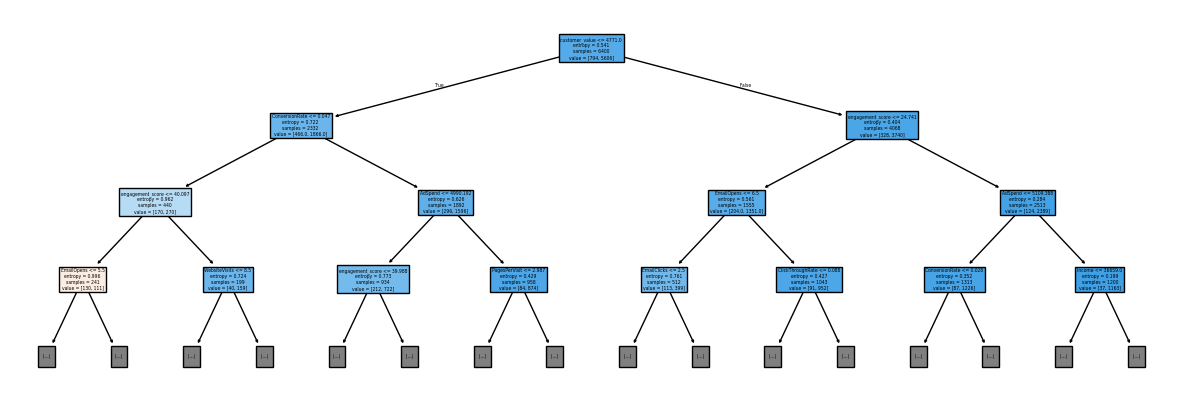

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plot_tree(
    tree_tree,
    feature_names=X.columns,
    filled=True,
    max_depth=3
)

plt.show()

In [ ]:
# for more graphical relations refer to logistic regression